### Generate data

In [29]:
import covasim as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools as it

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

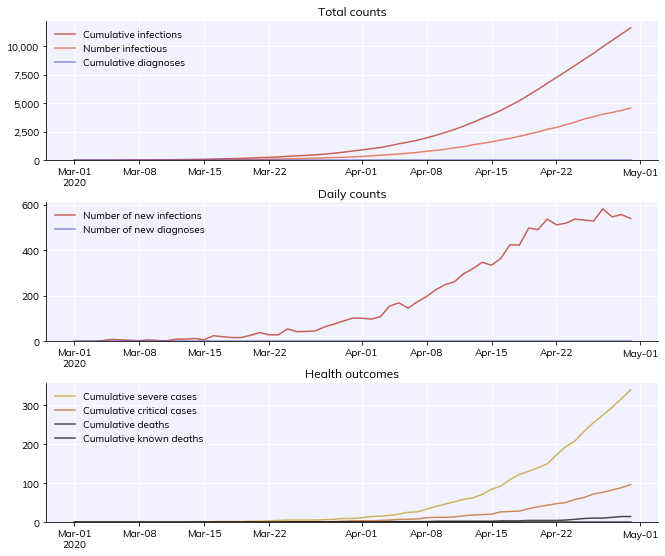

In [30]:
sim = cv.Sim(verbose=0)
sim.run().plot();

## One-dimensional sweep over beta to create `beta_sweep.csv`

In [31]:
betas = np.logspace(-2.25, -1.25, 100)
sims = []
for i, beta in enumerate(betas):
    sim = cv.Sim(beta=beta, rand_seed=i, label=f'Beta = {beta}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days


Initializing sim with 20000 people for 60 days
  Running "Beta = 0.005623413251903491": 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running "Beta = 0.0060298017058345935": 2020-03-01 ( 0/60) (0.19 s)  ———————————————————— 2%
  Running "Beta = 0.006932806692144524": 2020-03-01 ( 0/60) (0.20 s)  ———————————————————— 2%
  Running "Beta = 0.007433821372520386": 2020-03-01 ( 0/60) (0.20 s)  ———————————————————— 2%
  Running "Beta = 0.007971042992033401": 2020-03-01 ( 0/60) (0.20 s)  ———————————————————— 2%
  Running "Beta = 0.010537249727360731": 2020-03-01 ( 0/60)

MultiSim("Beta = 0.005623413251903491"; n_sims: 100; base: Sim("Beta = 0.005623413251903491"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

,log_beta,cum_inf
0,-2.250000,290.0
1,-2.239899,215.0
2,-2.229798,367.0
3,-2.219697,53.0
4,-2.209596,113.0
...,...,...
95,-1.290404,28676.0
96,-1.280303,29965.0
97,-1.270202,30126.0
98,-1.260101,29989.0


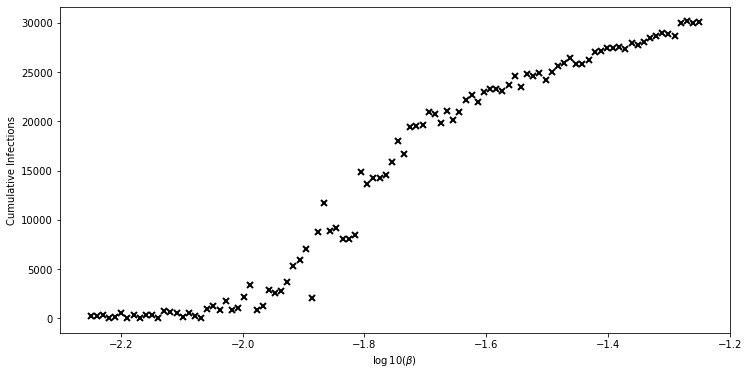

In [32]:
X = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X, 'cum_inf': Y})
display(df)
df.to_csv('sweep_beta.csv')

f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');

## Two dimensional

In [33]:
betas = np.logspace(-2.25, -1.25, 20)
pop_infs = np.linspace(10, 1000, 20)

z = list(it.product(betas, pop_infs))

sims = []
for i, (beta, pop_inf) in enumerate(z):
    sim = cv.Sim(beta=beta, pop_infected=pop_inf, rand_seed=i, label=f'Beta = {beta}, Seeds = {pop_inf}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days


Initializing sim with 20000 people for 60 days
  Running "Beta = 0.005623413251903491, Seeds = 10.0": 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%—————————— 2%

  Running "Beta = 0.00634792195935048, Seeds = 10.0": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.005623413251903491, Seeds = 10.0": 2020-03-11 (10/60) (0.15 s)  •••————————————————— 18%————————— 18%


  Running "Beta = 0.00808899816399594, Seeds = 10.0": 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%
  Running "Beta = 0.00634792195935048, Seeds = 10.0": 2020-03-11 (10/6

MultiSim("Beta = 0.005623413251903491, Seeds = 10.0"; n_sims: 400; base: Sim("Beta = 0.005623413251903491, Seeds = 10.0"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

cum_inf                                                        \
pop_infected     10       62       114      166      218      270      322    
log_beta                                                                      
-2.250000       230.0    320.0    978.0    815.0   1063.0   1666.0   1808.0   
-2.197368       106.0    442.0   1409.0   1551.0   2126.0   2715.0   2254.0   
-2.144737        14.0    794.0   1346.0   1818.0   2999.0   3772.0   4424.0   
-2.092105        54.0   2393.0   2429.0   3863.0   4659.0   5764.0   6147.0   
-2.039474       293.0   2526.0   4752.0   5848.0   7146.0   7461.0   8121.0   
-1.986842       928.0   5341.0   7347.0   7815.0   9150.0  11150.0  10732.0   
-1.934211       253.0   8788.0  10221.0  12039.0  11832.0  14078.0  14546.0   
-1.881579      3859.0  13345.0  13466.0  15229.0  16362.0  16199.0  16707.0   
-1.828947      5997.0  15304.0  17026.0  17345.0  18896.0  18842.0  18888.0   
-1.776316      4297.0  17495.0  19341.0  20227.0  20293.0  20591.0  20876.0   
-1.723684     13287.0  20812.0  21194.0  21692.0  21969.0  22049.0  22630.0   
-1.671053     13205.0  21915.0  22531.0  23215.0  23028.0  23238.0  23286.0   
-1.618421     23158.0  22915.0  23682.0  24175.0  24260.0  24107.0  24494.0   
-1.565789     21271.0  24606.0  24589.0  24907.0  25200.0  25395.0  25291.0   
-1.513158     23421.0  25375.0  25637.0  26034.0  26007.0  26373.0  26356.0   
-1.460526     25935.0  26818.0  26912.0  27140.0  27107.0  27239.0  27266.0   
-1.407895     26509.0  27294.0  27879.0  27983.0  27867.0  28210.0  28465.0   
-1.355263     25370.0  28262.0  28873.0  29253.0  28907.0  28877.0  29258.0   
-1.302632     27962.0  29930.0  29718.0  30317.0  30286.0  30653.0  30494.0   
-1.250000     30127.0  30791.0  30889.0  31187.0  31577.0  31200.0  31792.0   

                                                                             \
pop_infected     374      426      478      531      583      635      687    
log_beta                                                                      
-2.250000      2554.0   2646.0   2769.0   3107.0   3490.0   3868.0   3742.0   
-2.197368      3283.0   3102.0   3870.0   4335.0   4320.0   4825.0   4961.0   
-2.144737      4945.0   3818.0   4509.0   5474.0   5853.0   6211.0   7235.0   
-2.092105      5741.0   6615.0   7654.0   7032.0   8468.0   8527.0   8364.0   
-2.039474      9125.0   9807.0  10386.0  10813.0  11888.0  11224.0  10090.0   
-1.986842     12056.0  12514.0  12448.0  13045.0  13396.0  13932.0  14017.0   
-1.934211     14747.0  14345.0  15570.0  16064.0  16290.0  16059.0  16707.0   
-1.881579     17009.0  17854.0  18147.0  18277.0  18396.0  18512.0  18468.0   
-1.828947     19117.0  19664.0  19800.0  19591.0  19994.0  20249.0  20277.0   
-1.776316     21124.0  21300.0  21400.0  21496.0  21869.0  21918.0  21927.0   
-1.723684     22513.0  22498.0  22658.0  22675.0  22742.0  22797.0  23017.0   
-1.671053     23413.0  23660.0  23661.0  23848.0  23935.0  24017.0  23999.0   
-1.618421     24852.0  24638.0  24687.0  24612.0  24995.0  24936.0  25010.0   
-1.565789     25517.0  25431.0  25818.0  25782.0  25903.0  25735.0  25874.0   
-1.513158     26675.0  26325.0  26717.0  26640.0  26582.0  26925.0  26835.0   
-1.460526     27501.0  27281.0  27244.0  27370.0  27848.0  27718.0  27690.0   
-1.407895     28231.0  28416.0  28309.0  28722.0  28910.0  28631.0  28754.0   
-1.355263     29327.0  29543.0  29384.0  29540.0  29732.0  29593.0  29904.0   
-1.302632     30785.0  30628.0  30719.0  30745.0  30396.0  30728.0  30614.0   
-1.250000     31661.0  31815.0  31521.0  31785.0  31932.0  32152.0  32314.0   

                                                                    
pop_infected     739      791      843      895      947      1000  
log_beta                                                            
-2.250000      4319.0   4428.0   4574.0   4472.0   4839.0   4900.0  
-2.197368      5085.0   5624.0   5922.0   5398.0   6877.0   6576.0  
-2.144737      6588.0   7234.0   

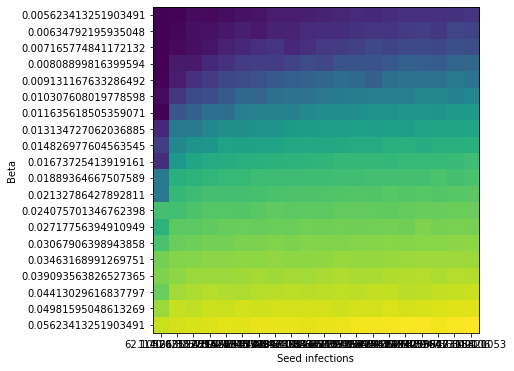

In [34]:
X1 = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
X2 = np.array([s.pars['pop_infected'] for s in msim.sims])
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X1, 'pop_infected': X2, 'cum_inf': Y})
df.to_csv('sweep_beta_popinf.csv')

dfp = df.set_index(['log_beta', 'pop_infected']).unstack('pop_infected')
display(dfp)
plt.imshow(dfp)

plt.xlabel('Seed infections');
plt.xticks(ticks=range(len(pop_infs)), labels=pop_infs);

plt.ylabel('Beta')
plt.yticks(ticks=range(len(betas)), labels=betas);